# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

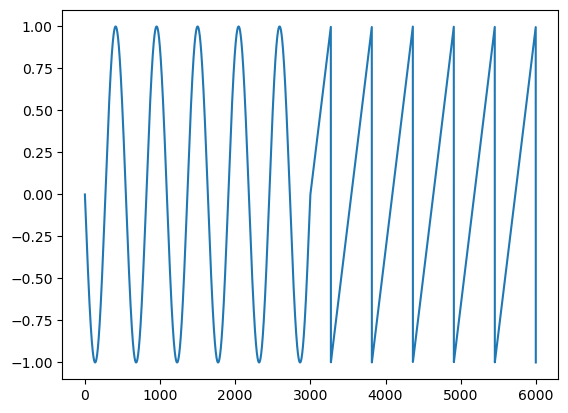

In [3]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [4]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


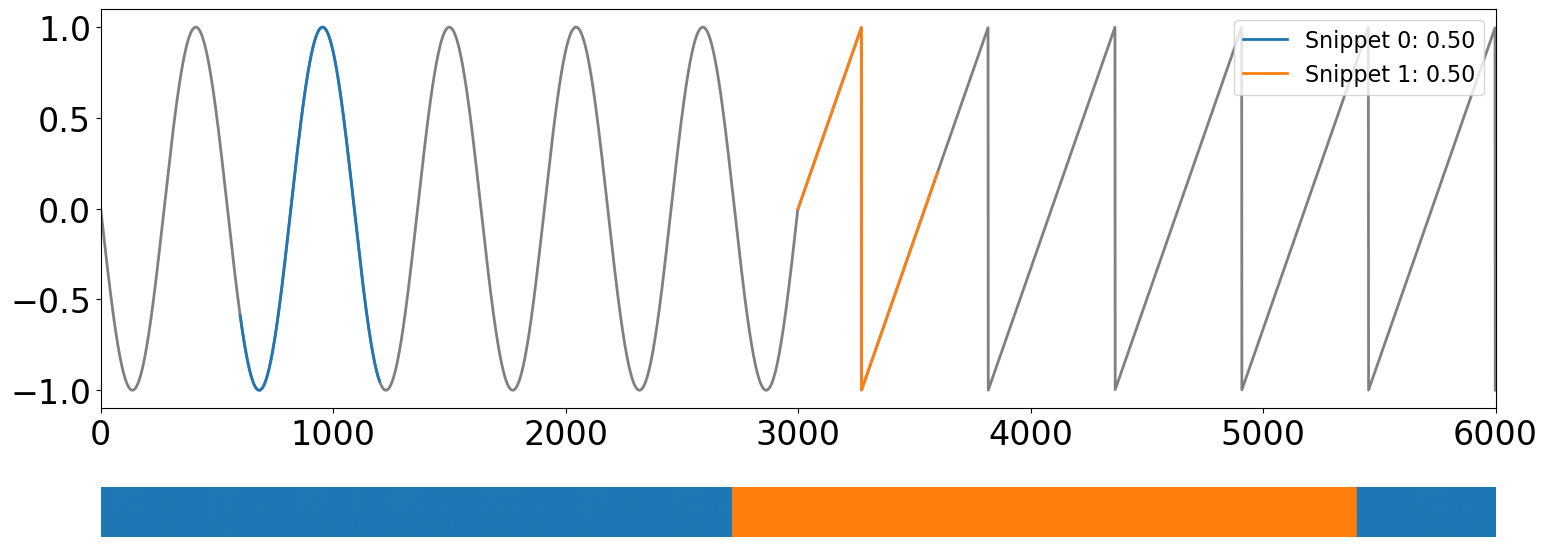

<Axes: >

In [5]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [6]:
pamap = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

start = 1790
end = 1930

timestamp = pamap[0]
interval_mask = (timestamp >= start) & (timestamp <= end)

gyroscope = pamap[11][interval_mask]

In [7]:
snp = snippets(gyroscope, 600, 2, percentage=0.5)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


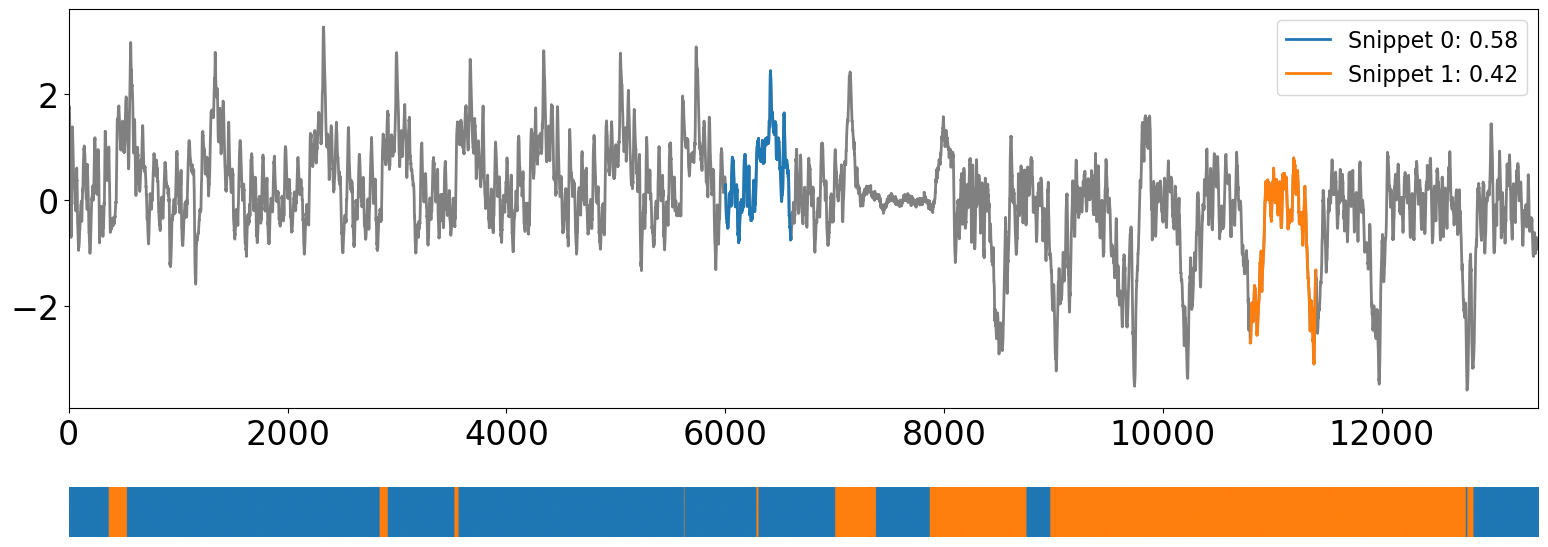

<Axes: >

In [8]:
plot_snippets(gyroscope, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [9]:
from sklearn.metrics import accuracy_score
activity_ids = pamap[1]
activity_ids = activity_ids[interval_mask]
activity_ids -= activity_ids.min()

snp_activity_ids = np.zeros(len(activity_ids))
for value, start, end in snp[-1]:
    snp_activity_ids[start:end] = value

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"accuracy: {accuracy*100:.2f}%")

accuracy: 86.35%


Сниппеты хорошо представляют типичные паттерны активностей. Результаты показывают, что алгоритм способен автоматически выделять повторяющиеся и характерные движения.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

900


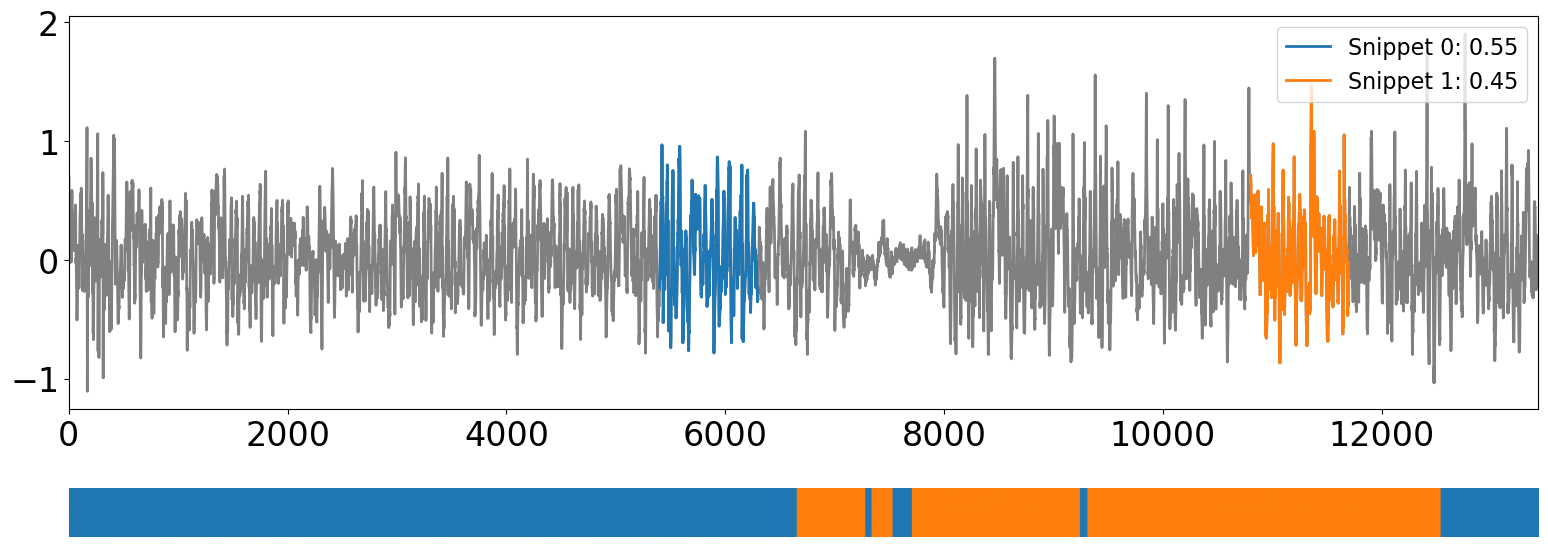

900


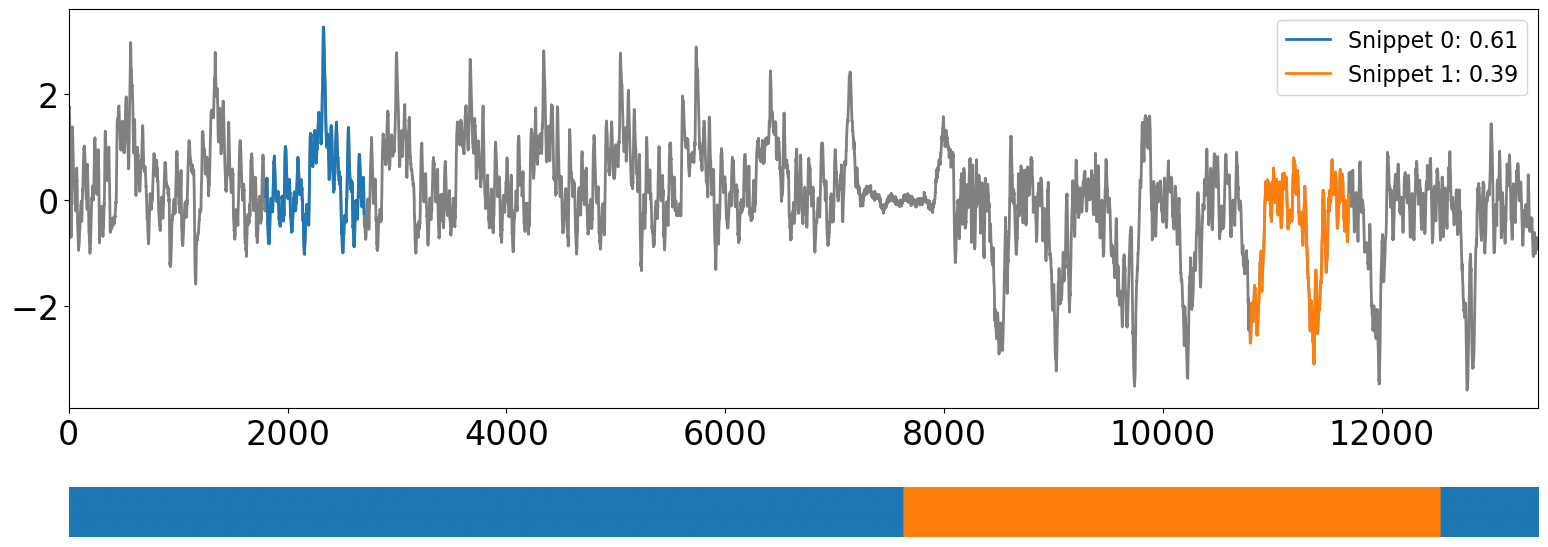

900


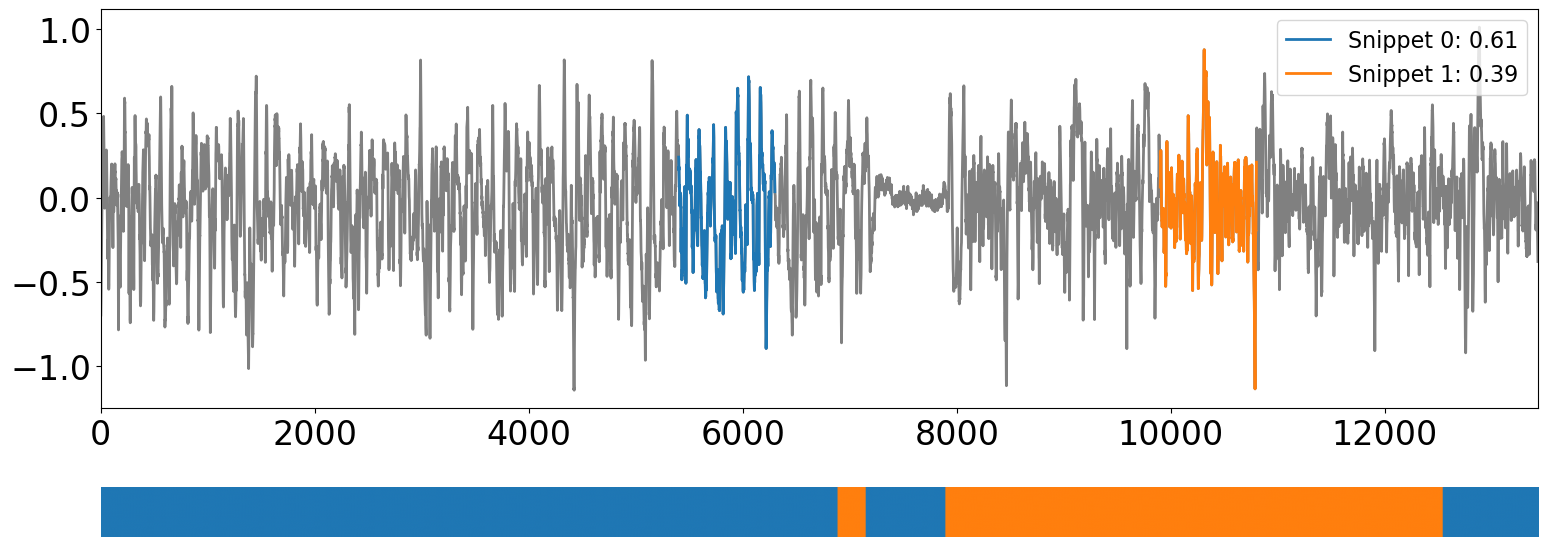

In [10]:
gyroscope_x = pamap[10][interval_mask]
snp_x = snippets(gyroscope_x, 900, 2, percentage=0.5)

plot_snippets(gyroscope_x, snp_x)

snp_activity_ids_x = np.zeros(len(gyroscope_x))
for value, start, end in snp_x[-1]:
    snp_activity_ids_x[start:end] = value


gyroscope_y = pamap[11][interval_mask]

snp_y = snippets(gyroscope_y, 900, 2, percentage=0.5)

plot_snippets(gyroscope_y, snp_y)

snp_activity_ids_y = np.zeros(len(gyroscope_y))
for value, start, end in snp_y[-1]:
    snp_activity_ids_y[start:end] = value


gyroscope_z = pamap[12][interval_mask]

snp_z = snippets(gyroscope_z, 900, 2, percentage=0.5)

plot_snippets(gyroscope_z, snp_z)

snp_activity_ids_z = np.zeros(len(gyroscope_z))
for value, start, end in snp_z[-1]:
    snp_activity_ids_z[start:end] = value

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [11]:
snp_activity_ids = []
for i in range(len(gyroscope_x)):
    votes = [snp_activity_ids_x[i], snp_activity_ids_y[i], snp_activity_ids_z[i]]
    snp_activity_ids.append(np.bincount(votes).argmax())

snp_activity_ids = np.array(snp_activity_ids)

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"{accuracy*100:.2f}%")

90.13%


Использование всех 3 осей дает большую точность относительно одной из других осей

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [12]:
profile_areas = []

for K in range(1, 5):
    snp_x, snp_y, snp_z = (snippets(data, 10, K, percentage=0.5)
                           for data in (gyroscope_x, gyroscope_y, gyroscope_z))

    profile_area = np.min([snp_x[-2][k] + snp_y[-2][k] + snp_z[-2][k]
                           for k in range(K)])

    profile_areas.append(profile_area)

changes = [profile_areas[k - 1] / profile_areas[k] - 1 for k in range(1, 4)]

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

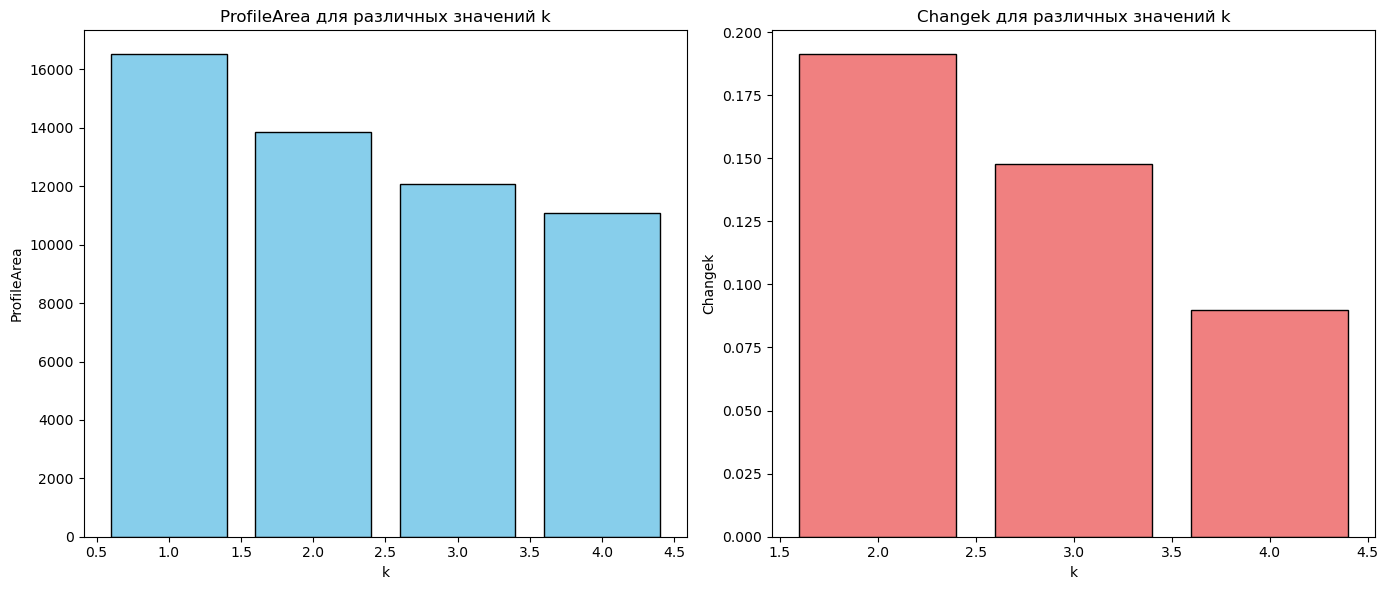

In [16]:
kvalues = np.arange(1, 5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(kvalues, profile_areas, color='skyblue', edgecolor='black')
ax1.set_title('ProfileArea для различных значений k')
ax1.set_xlabel('k')
ax1.set_ylabel('ProfileArea')

ax2.bar(kvalues[1:], changes, color='lightcoral', edgecolor='black')
ax2.set_title('Changek для различных значений k')
ax2.set_xlabel('k')
ax2.set_ylabel('Changek')

plt.tight_layout()
plt.show()

Анализ полученных результатов на основе графиков ProfileArea и Change позволяет выявить ключевые особенности зависимости между размером сниппета k и характеристиками временного ряда, а также помочь выбрать оптимальное значение k.

Наилучшее значение k = 2 следует, из-за наибольшего значения Change.